In [2]:
import itertools
from copy import deepcopy

import numpy as np
print(f'numpy version: {np.__version__}')
from pathlib import Path
from uncertainties import ufloat
from astropy.io import ascii
import pandas as pd
from astropy.table import Table
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib as mpl
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel
from species.plot.plot_spectrum import plot_spectrum
import astropy.units as u
from astropy.io import fits, ascii

import urllib
from species import SpeciesInit
from species.data.database import Database
from species.fit.compare_spectra import CompareSpectra
from species.read.read_model import ReadModel
from species.plot.plot_comparison import plot_grid_statistic, plot_model_spectra
from species.plot.plot_spectrum import plot_spectrum
from species.util.box_util import update_objectbox
from species.util.fit_util import get_residuals
from species.phot.syn_phot import SyntheticPhotometry
# Set target

spec_file = f'./input/spectrum.fits'
spectrum = Table(fits.getdata(spec_file))   # flux in W m-2 um-2
display(spectrum)


numpy version: 1.24.3


/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WAVELENGTH,FLUX,COVARIANCE,CONTRAST,COVARIANCE_CONTRAST
float64,float64,float64[233],float64,float64[233]
1.9700000286102295,1.718685067351534e-16,1.9484786223401413e-33 .. 4.0221453531065934e-36,0.0007728486571293201,3.921080451503715e-08 .. -8.048846725104785e-11
1.9721983671188354,1.4089921411517234e-16,6.852990484573557e-35 .. 3.615809182479277e-36,0.0006535989157681976,1.2674094571333896e-09 .. -8.18714952618767e-11
1.9743965864181519,1.2533557849524717e-16,6.671393976864422e-35 .. 3.503821581228739e-36,0.0005953242530946998,1.2705674561159345e-09 .. -6.038050332381896e-11
1.9765948057174683,9.863676391540741e-17,6.08922121701629e-35 .. 1.4900786172500139e-36,0.0004984755184902698,1.2394233269310896e-09 .. -9.547631312963002e-11
1.9787930250167847,1.4060213234633553e-16,6.026702657328904e-35 .. 2.515247346851541e-36,0.0007398549782708634,1.2010573170468263e-09 .. -1.0218809103875521e-10
1.9809913635253906,1.4077030832949073e-16,6.089489998482279e-35 .. 2.6160634493269732e-36,0.0006854020459102524,1.1442505695598075e-09 .. -9.889162701785543e-11
1.983189582824707,1.345765235114303e-16,5.835043503237192e-35 .. 2.803525200426341e-36,0.0006401706136820693,1.0786370841547919e-09 .. -7.642151290165014e-11
1.9853878021240234,1.4482320319760133e-16,5.32035211244626e-35 .. 2.6787305112352336e-36,0.0007335911728084893,1.003498897135029e-09 .. -1.1074591877970416e-10
1.987586259841919,1.3123227619086782e-16,4.930911606447484e-35 .. 2.9834192315033194e-36,0.0006653310454656022,9.37401349783386e-10 .. -6.572936687315546e-11


In [3]:
# species test below
SpeciesInit()
database = Database()
parallax = ufloat(7.464925176349439, 0.021432146)


species v0.9.0

 -> A new version (0.10.0) is available!
 -> It is recommended to update to the latest version
 -> See https://github.com/tomasstolker/species for details

Working folder: /Users/rvc/github/wispit_2c

Configuration file: /Users/rvc/github/wispit_2c/species_config.ini
Database file: /Users/rvc/github/wispit_2c/species_database.hdf5
Data folder: /Users/rvc/github/wispit_2c/data

Configuration settings:
   - Database: /Users/rvc/github/wispit_2c/species_database.hdf5
   - Data folder: /Users/rvc/github/wispit_2c/data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


In [4]:
# star magnitude
app_star = ufloat(8.591, 0.078)
contrast_2c = ufloat(7.39, 0.21)
app_2c = app_star + contrast_2c

# MagAO-X
app_2c_zp = ufloat(19.40, 0.65)
# LBT
app_2c_l = ufloat(14.80, 0.76)

# add sphere data point
#synphot = SyntheticPhotometry('Paranal/SPHERE.IRDIS_B_H')
synphot = SyntheticPhotometry('2MASS/2MASS.H')
flux, error = synphot.magnitude_to_flux(app_2c.n, error=app_2c.s)
print(f'Flux (W m-2 um-1) = {flux:.2e} +/- {error:.2e}')



Flux (W m-2 um-1) = 4.63e-16 +/- 9.61e-17


In [5]:
database.delete_data("objects/WISPIT 2 c")
database.delete_data("objects/WISPIT2c")

#database.add_object(object_name='WISPIT 2 c',
#                    app_mag={'2MASS/2MASS.H':(app_2c.n, app_2c.s)},
#                    parallax=(parallax.n, parallax.s),
#                    spectrum={'GRAVITY': (spec_file,
#                                          spec_file,
#                                          500.)})

database.add_object(object_name='WISPIT 2 c',
                    app_mag={'2MASS/2MASS.H':(app_2c.n, app_2c.s),
                             'LCO/MagAOX.Sci1-zp':(app_2c_zp.n,app_2c_zp.s),
                             'LBT/LMIRCam.L_77K':(app_2c_l.n,app_2c_l.s)},
                    parallax=(parallax.n, parallax.s),
                    spectrum={'GRAVITY': (spec_file,
                                          spec_file,
                                          500.)})


Deleting data: objects/WISPIT 2 c... [DONE]

----------
Add object
----------

Object name: WISPIT 2 c
Units: None
Deredden: None
Parallax (mas) = 7.46 +/- 0.02

Magnitudes:
   - 2MASS/2MASS.H:
      - Mean wavelength (um) = 3.7035e+00
      - Apparent magnitude = 15.98 +/- 0.22
      - Flux (W m-2 um-1) = 4.63e-16 +/- 9.61e-17
   - LCO/MagAOX.Sci1-zp:
      - Mean wavelength (um) = 3.7035e+00
      - Apparent magnitude = 19.40 +/- 0.65
      - Flux (W m-2 um-1) = 1.45e-16 +/- 9.19e-17
   - LBT/LMIRCam.L_77K:
      - Mean wavelength (um) = 3.7035e+00
      - Apparent magnitude = 14.80 +/- 0.76
      - Flux (W m-2 um-1) = 6.88e-17 +/- 5.22e-17

Spectra:
   - GRAVITY spectrum:
      - Object: Unknown
      - Database tag: GRAVITY
      - Filename: ./input/spectrum.fits
      - Data shape: (233, 3)
      - Wavelength range (um): 1.97 - 2.48
      - Mean flux (W m-2 um-1): 1.48e-16
      - Mean error (W m-2 um-1): 1.00e-17
   - GRAVITY covariance matrix:
      - Object: Unknown
      - Dat

/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-packages/species/data/database.py:299: UserWarning: The dataset objects/WISPIT2c is not found in species_database.hdf5.
  warnings.warn(


In [17]:
database.available_models()
#modelname = 'atmo-petrus2023'
modelname = 'exo-rem-highres'




-----------------------
Available model spectra
-----------------------

   - AMES-Cond:
      - Label = ames-cond
      - Model parameters: ['teff', 'logg']
      - Teff range (K): [100, 6600]
      - Wavelength range (um): [0.5, 40]
      - Sampling (lambda/d_lambda): 4000
      - File size: 150 MB

   - AMES-Dusty:
      - Label = ames-dusty
      - Model parameters: ['teff', 'logg']
      - Teff range (K): [500, 4000]
      - Wavelength range (um): [0.5, 40]
      - Sampling (lambda/d_lambda): 4000
      - File size: 58 MB

   - ATMO:
      - Label = atmo
      - Model parameters: ['teff', 'logg']
      - Teff range (K): [200, 3000]
      - Wavelength range (um): [0.4, 6000]
      - Sampling (lambda/d_lambda): 1000
      - File size: 45 MB
      - Reference: Phillips et al. (2020)
      - URL: https://ui.adsabs.harvard.edu/abs/2020A%26A...637A..38P

   - ATMO CEQ:
      - Label = atmo-ceq
      - Model parameters: ['teff', 'logg']
      - Teff range (K): [200, 3000]
      - Wavele

In [23]:
database.add_model(modelname, teff_range=(1600., 2200.), wavel_range=(0.5, 4.5))



-------------------------
Add grid of model spectra
-------------------------

Database tag: exo-rem-highres
Model name: Exo-REM

Unpacking 3576/13403 model spectra from Exo-REM (22 GB)... [DONE]

Please cite Charnay et al. (2018) when using Exo-REM in a publication
Reference URL: https://ui.adsabs.harvard.edu/abs/2018ApJ...854..172C

Wavelength range (um) = 0.5 - 4.5
Sampling (lambda/d_lambda) = 20000
Teff range (K) = 1600.0 - 2200.0

Adding Exo-REM model spectra... data/exo-rem-highres/exo-rem-highres_teff_2000_logg_5.0_feh_2.0_co_0.80_spec.npy 

Grid points stored in the database:
   - Teff = [1600. 1650. 1700. 1750. 1800. 1850. 1900. 1950. 2000.]
   - log(g) = [3.  3.5 4.  4.5 5. ]
   - [Fe/H] = [-0.5  0.   0.5  1.   1.5  2. ]
   - C/O = [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8 ]

Number of grid points per parameter:
   - teff: 9
   - logg: 5
   - feh: 6
   - c_o_ratio: 15
   - teff = 1600.0, logg = 3.0, feh = -0.5, c_o_ratio = 0.15
   - teff = 1

In [30]:
compare = CompareSpectra(object_name='WISPIT 2 c',
                         spec_name=['GRAVITY'])

In [31]:
fix_logg = 4.


In [32]:
compare.compare_model(tag='WISPIT2c',
                      model=modelname,
                      av_points=None,
                      fix_logg=fix_logg,
                      scale_spec=None,
                      weights=True,
                      inc_phot=True)

Available photometric data for WISPIT 2 c:
   - 2MASS/2MASS.H
   - LBT/LMIRCam.L_77K
   - LCO/MagAOX.Sci1-zp
Processing model spectrum 717/810...

/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-packages/species/fit/compare_spectra.py:594: UserWarning: The extracted model spectrum contains 233 fluxes with NaN. Probably because some of the wavelengths of the data are outside the available wavelength range of the model grid. These wavelengths are ignored when calculating the goodness-of-fit statistic.
  warnings.warn(
/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-packages/species/phot/syn_phot.py:189: UserWarning: Found 37581 fluxes with NaN. Removing these spectral fluxes from the input data before calculating synthetic photometry.
  warnings.warn(
/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-packages/species/phot/syn_phot.py:227: UserWarning: Calculation of the mean flux for 2MASS/2MASS.H is not possible because the wavelength array is empty. Returning a NaN for the flux.
  warnings.warn(
/Users/rvc/Programs/miniconda3/envs/vltsphere_iso/lib/python3.11/site-pa

Processing model spectrum 810/810... [DONE]
Best-fit parameters:
   - Goodness-of-fit = 1.34e+00
   - teff = 1850.0
   - logg = 4.0
   - feh = -0.5
   - c_o_ratio = 0.7
   - Radius (Rjup) = 1.80
   - Scaling = 9.70e-22


In [33]:
#fig = plot_grid_statistic(tag='WISPIT2c',
#                          upsample=False,
#                          offset=None,
#                          output=None,
#                          extra_param='radius',
#                          nlevels_main=10,
#                          nlevels_extra=5)

Plotting model spectra comparison...

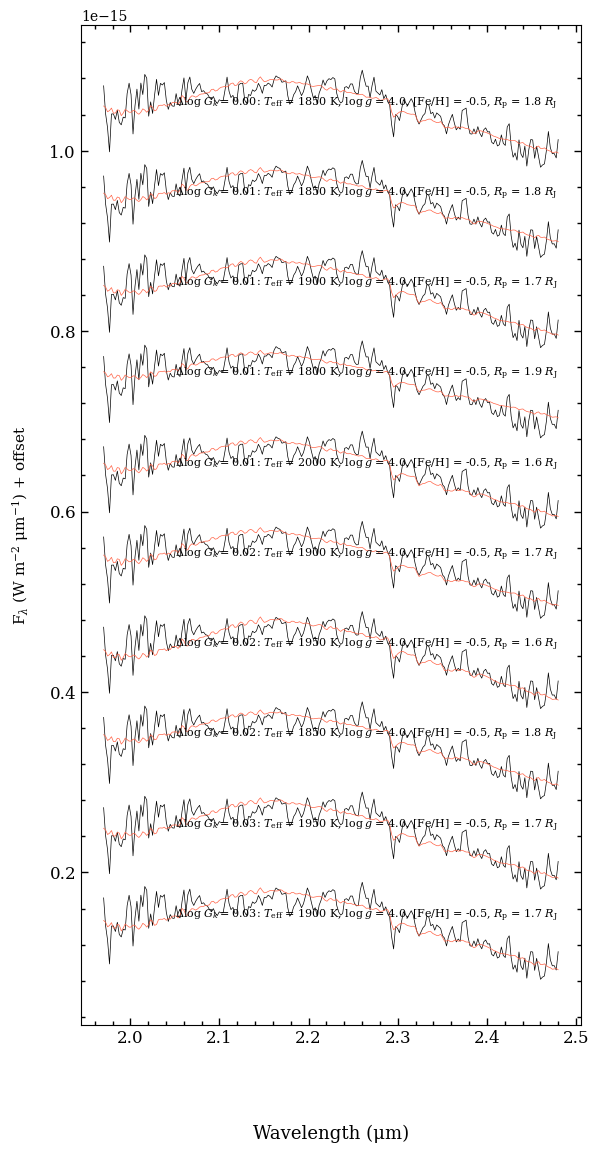

 [DONE]


In [34]:
fig = plot_model_spectra(tag='WISPIT2c',
                         n_spectra=10,
                         flux_offset=1e-16,
                         label_pos=(2.05, 1.5e-16),
                         xlim=None,
                         ylim=None,
                         title=None,
                         offset=None,
                         figsize=(5., 10.),
                         output=None,
                         leg_param=['teff', 'logg', 'feh', 'radius'])
fig.savefig(f'./output/spectra/{modelname}_logg_{str(fix_logg)}_comparison_allphot.png')


In [35]:
best = database.get_compare_sample('WISPIT2c')



------------------------------
Get best comparison parameters
------------------------------

Database tag: WISPIT2c

Parameters:
   - teff = 1850.00
   - logg = 4.00
   - feh = -0.50
   - c_o_ratio = 0.70
   - parallax = 7.46
   - radius = 1.80


In [36]:
object_box = database.get_object(object_name='WISPIT 2 c',
                                 inc_phot=True,
                                 inc_spec=True)


----------
Get object
----------

Object name: WISPIT 2 c
Include photometry: True
Include spectra: True


In [37]:
read_model = ReadModel(modelname)
model_box = read_model.get_model(best, spec_res=500.)

In [38]:
residuals = get_residuals(datatype='model',
                          spectrum=modelname,
                          tag='WISPIT2c',
                          parameters=best,
                          objectbox=object_box,
                          inc_phot=True,
                          inc_spec=True)


-------------------
Calculate residuals
-------------------

Selected results: CompareSpectra
Model: exo-rem-highres

Model parameters:
   - teff
   - logg
   - feh
   - c_o_ratio

Fixed parameters: none

Include photometry: True
Include spectra: True

Residuals (sigma):
   - 2MASS/2MASS.H = 1.24
   - LBT/LMIRCam.L_77K = 0.12
   - LCO/MagAOX.Sci1-zp = -0.56
   - GRAVITY: min = -3.48, max = 3.15

Number of data points = 236
Number of model parameters = 4
Number of fixed parameters = 0
Number of degrees of freedom = 232

chi2 = 406.48
reduced chi2 = 1.75



-------------
Plot spectrum
-------------

Boxes:
   - ModelBox
   - ObjectBox

Object type: planet
Quantity: flux density
Units: ('um', 'W m-2 um-1')
Filter profiles: None

Figure size: (6.0, 3.0)
Legend parameters: None
Include model name: False
Font sizes: {'xlabel': 11.0, 'ylabel': 11.0, 'title': 13.0, 'legend': 9.0}


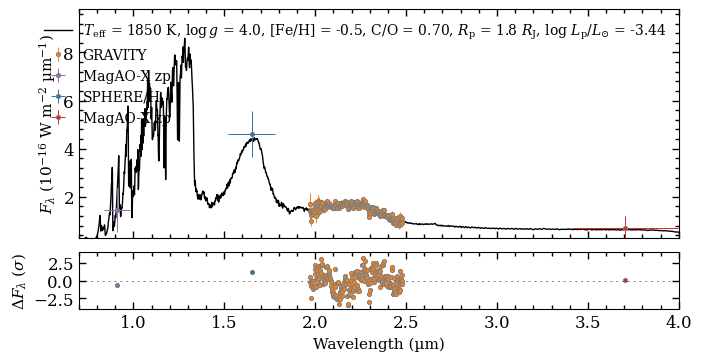


-------------
Plot spectrum
-------------

Boxes:
   - ModelBox
   - ObjectBox

Object type: planet
Quantity: flux density
Units: ('um', 'W m-2 um-1')
Filter profiles: None

Figure size: (6.0, 3.0)
Legend parameters: None
Include model name: False
Font sizes: {'xlabel': 11.0, 'ylabel': 11.0, 'title': 13.0, 'legend': 9.0}


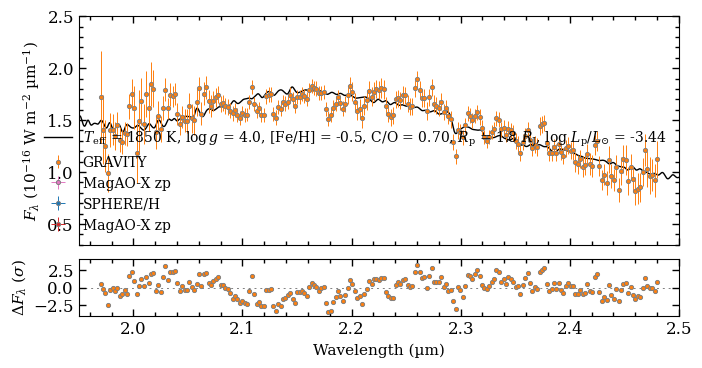

In [39]:
#fig = plot_spectrum(boxes=[model_box, object_box],
#                    filters=None,
#                    residuals=residuals,
#                    plot_kwargs=[{'ls': '-', 'lw': 1., 'color': 'black'},
#                                 {'2MASS/2MASS.H': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:blue', 'ls': 'none', 'label': 'SPHERE/H'},
#                                 'GRAVITY': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:orange', 'ls': 'none', 'label': 'GRAVITY'}}],
#                    xlim=(1.2, 2.5),
#                    #xlim=(2.0, 2.5),
#                    #ylim=(0.3e-16, 9.8e-16),
#                    ylim=(0.3e-16, 5.8e-16),
#                    scale=('linear', 'linear'),
#                    quantity='flux density',
#                    legend={'loc': 'lower right', 'frameon': False, 'fontsize': 10.},
#                    output=None)
#fig.savefig(f'./output/spectra/{modelname}_logg_{str(fix_logg)}_bestfit.png')
#
#fig = plot_spectrum(boxes=[model_box, object_box],
#                    filters=None,
#                    residuals=residuals,
#                    plot_kwargs=[{'ls': '-', 'lw': 1., 'color': 'black'},
#                                 {'2MASS/2MASS.H': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:blue', 'ls': 'none', 'label': 'SPHERE/H'},
#                                  'GRAVITY': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:orange', 'ls': 'none', 'label': 'GRAVITY'}}],
#                    #xlim=(1.2, 2.5),
#                    xlim=(1.95, 2.5),
#                    #ylim=(0.3e-16, 9.8e-16),
#                    ylim=(0.3e-16, 2.5e-16),
#                    scale=('linear', 'linear'),
#                    quantity='flux density',
#                    legend={'loc': 'lower right', 'frameon': False, 'fontsize': 10.},
#                    output=None)
#fig.savefig(f'./output/spectra/{modelname}_logg_{str(fix_logg)}_bestfit_zoom.png')


fig = plot_spectrum(boxes=[model_box, object_box],
                    filters=None,
                    residuals=residuals,
                    plot_kwargs=[{'ls': '-', 'lw': 1., 'color': 'black'},
                                 {'2MASS/2MASS.H': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:blue', 'ls': 'none', 'label': 'SPHERE/H'},
                                  'LCO/MagAOX.Sci1-zp': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:purple', 'ls': 'none', 'label': 'MagAO-X zp'},
                                  'LBT/LMIRCam.L_77K': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:red', 'ls': 'none', 'label': 'MagAO-X zp'},
                                  'GRAVITY': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:orange', 'ls': 'none', 'label': 'GRAVITY'}}],
                    xlim=(0.7, 4),
                    #xlim=(2.0, 2.5),
                    #ylim=(0.3e-16, 9.8e-16),
                    ylim=(0.3e-16, 9.8e-16),
                    scale=('linear', 'linear'),
                    quantity='flux density',
                    legend={'loc': 'best', 'frameon': False, 'fontsize': 10.},
                    output=None)
fig.savefig(f'./output/spectra/{modelname}_logg_{str(fix_logg)}_bestfit_allphot.png')

fig = plot_spectrum(boxes=[model_box, object_box],
                    filters=None,
                    residuals=residuals,
                    plot_kwargs=[{'ls': '-', 'lw': 1., 'color': 'black'},
                                 {'2MASS/2MASS.H': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:blue', 'ls': 'none', 'label': 'SPHERE/H'},
                                  'LCO/MagAOX.Sci1-zp': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:pink', 'ls': 'none', 'label': 'MagAO-X zp'},
                                  'LBT/LMIRCam.L_77K': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:red', 'ls': 'none', 'label': 'MagAO-X zp'},
                                  'GRAVITY': {'marker': 'o', 'ms': 3., 'elinewidth': 0.7, 'mew': 0.7, 'mec': 'gray', 'color': 'tab:orange', 'ls': 'none', 'label': 'GRAVITY'}}],
                    #xlim=(1.2, 2.5),
                    xlim=(1.95, 2.5),
                    #ylim=(0.3e-16, 9.8e-16),
                    ylim=(0.3e-16, 2.5e-16),
                    scale=('linear', 'linear'),
                    quantity='flux density',
                    legend={'loc': 'best', 'frameon': False, 'fontsize': 10.},
                    output=None)
fig.savefig(f'./output/spectra/{modelname}_logg_{str(fix_logg)}_bestfit_allphot_zoom.png')




In [40]:
# manually get the low res parameters in high res model
print(best)
manual_best = best.copy()
#manual_best = database.get_compare_sample('WISPIT2c')

#residuals = get_residuals(datatype='model',
#                          spectrum=modelname,
#                          tag='WISPIT2c',
#                          parameters=best,
#                          objectbox=object_box,
#                          inc_phot=True,
#                          inc_spec=True)


{'teff': 1850.0, 'logg': 4.0, 'feh': -0.5, 'c_o_ratio': 0.7, 'parallax': 7.464925176349439, 'radius': 1.8004961980799143, 'log_lum_atm': -3.442164104138766, 'log_lum': -3.442164104138766, 'mass': 13.078829249986626}


In [41]:


from species.plot.plot_mcmc import plot_posterior
# Corner plot from posterior
plot_posterior(
    tag='WISPIT2c',
    inc_mass=True,
    inc_luminosity=True,
    offset=(-0.25, -0.25),
    output='candidate_corner.pdf',
)
print("Saved corner plot to candidate_corner.pdf")



---------------------
Get posterior samples
---------------------



KeyError: 'Unable to open object (component not found)'